# AI Engineer Roadmap
## Deep Learning
### https://zazencodes.com/courses/ai-engineer-roadmap#deep-learning

In [1]:
import numpy as np

class Perceptron:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        """
        Initialize perceptron with learning rate and number of iterations
        """
        self.learning_rate = learning_rate  # Controls how much weights are updated
        self.n_iter = n_iter  # Number of passes over the training data
        self.weights = None  # Weight coefficients for each feature
        self.bias = None  # Bias term

    def fit(self, X, y):
        """
        Train the perceptron on training data X and labels y
        X: array of shape (n_samples, n_features)
        y: array of shape (n_samples,) with binary labels 0/1
        """
        # Initialize weights to zeros and bias to 0
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Training process - iterate n_iter times over all samples
        for _ in range(self.n_iter):
            for idx, x_i in enumerate(X):
                # Calculate predicted output for current sample
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_pred = self._activation(linear_output)

                # Update weights and bias based on prediction error
                update = self.learning_rate * (y[idx] - y_pred)
                self.weights += update * x_i  # Update each weight
                self.bias += update  # Update bias term

    def predict(self, X):
        """
        Make predictions on new samples X
        Returns binary predictions 0/1
        """
        linear_output = np.dot(X, self.weights) + self.bias
        return self._activation(linear_output)

    def _activation(self, x):
        """
        Step activation function that returns:
        1 if input >= 0
        0 if input < 0
        """
        return np.where(x >= 0, 1, 0)

# Create simple linearly-separable dataset
X = np.array([
    [2, 4], [1, 1], [2, 1], [3, 5], [1, 5],
    [4, 1], [5, 3], [4, 5], [2, 2], [3, 2]
])
y = np.array([1, 0, 0, 1, 1, 0, 1, 1, 0, 0])

# Instantiate and train the perceptron
perceptron = Perceptron(learning_rate=0.1, n_iter=10)
perceptron.fit(X, y)

# Predict and evaluate
print("Predictions (10 iters):", perceptron.predict(X))

# Increase number of learning iterations
perceptron = Perceptron(learning_rate=0.1, n_iter=100)
perceptron.fit(X, y)
print("Predictions (100 iter):", perceptron.predict(X))


Predictions (10 iters): [0 0 0 0 1 0 0 0 0 0]
Predictions (100 iter): [1 0 0 1 1 0 1 1 0 0]


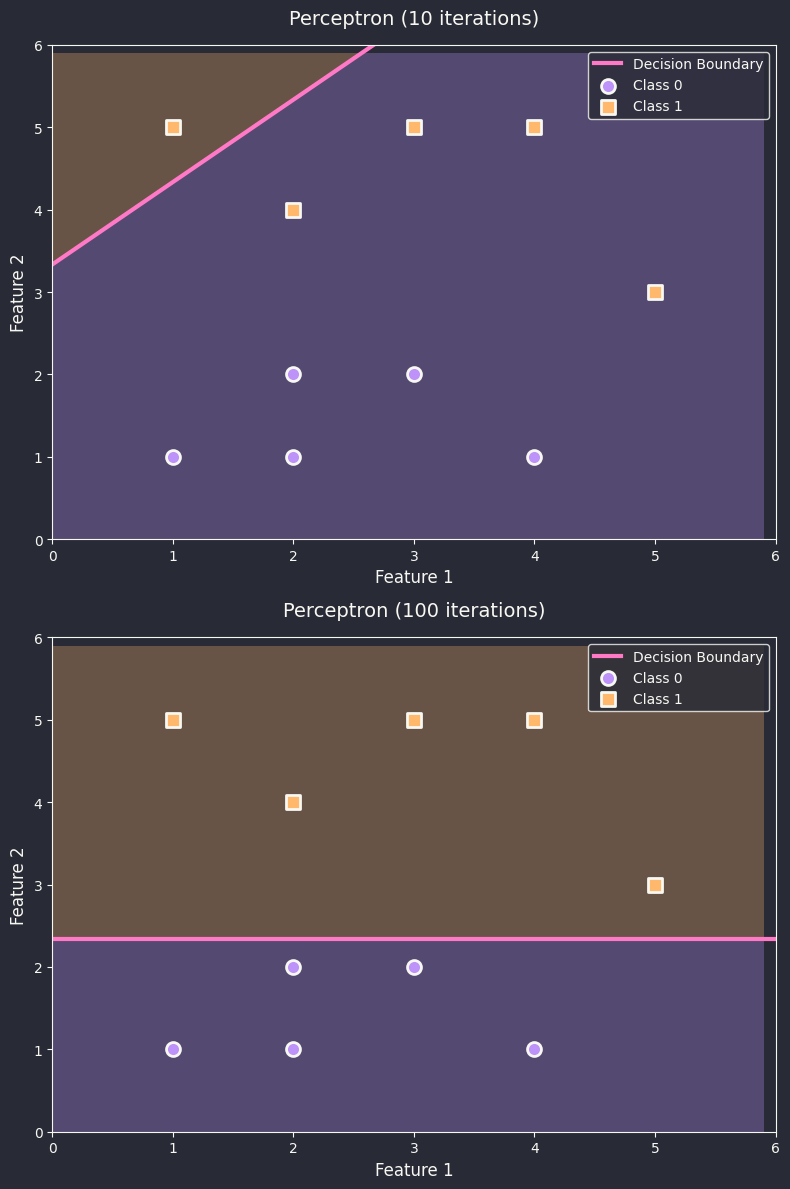

Accuracy (10 iterations): 0.60
Accuracy (100 iterations): 1.00
True labels:     [1 0 0 1 1 0 1 1 0 0]
Pred (10 iter):  [0 0 0 0 1 0 0 0 0 0]
Pred (100 iter): [1 0 0 1 1 0 1 1 0 0]


In [2]:
import matplotlib.pyplot as plt

# Dracula theme colors
BG_COLOR = '#282a36'  # Dark background
FG_COLOR = '#f8f8f2'  # Light foreground text
PURPLE   = '#BD93F9'  # Primary color
ORANGE   = '#FFB86C'  # Secondary color
PINK     = '#FF79C6'  # Tertiary color

def style_axes(ax):
    """Apply Dracula styling to axes."""
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors=FG_COLOR)
    for spine in ax.spines.values():
        spine.set_color(FG_COLOR)

def plot_perceptron_decision_boundary(X, y, perceptron, title, ax):
    """
    Plot the data points and decision boundary of the perceptron
    """
    # Create a mesh to plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Make predictions on the mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = perceptron.predict(mesh_points)
    Z = Z.reshape(xx.shape)
    
    # Plot the decision regions with proper colors
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, colors=[PURPLE, ORANGE])
    
    # Plot the decision boundary line (PINK)
    if perceptron.weights[1] != 0:  # Avoid division by zero
        # Decision boundary: w1*x1 + w2*x2 + bias = 0
        # Rearranged: x2 = -(w1*x1 + bias)/w2
        x_line = np.linspace(x_min, x_max, 100)
        y_line = -(perceptron.weights[0] * x_line + perceptron.bias) / perceptron.weights[1]
        ax.plot(x_line, y_line, color=PINK, linewidth=3, label='Decision Boundary')
    
    # Plot the data points
    class_0_idx = y == 0
    class_1_idx = y == 1
    
    ax.scatter(X[class_0_idx, 0], X[class_0_idx, 1], 
               c=PURPLE, marker='o', s=100, label='Class 0', 
               edgecolors=FG_COLOR, linewidth=2)
    ax.scatter(X[class_1_idx, 0], X[class_1_idx, 1], 
               c=ORANGE, marker='s', s=100, label='Class 1',
               edgecolors=FG_COLOR, linewidth=2)
    
    # Set axis limits to show decision boundary properly
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # Add title and labels
    ax.set_title(title, color=FG_COLOR, fontsize=14, pad=15)
    ax.set_xlabel('Feature 1', color=FG_COLOR, fontsize=12)
    ax.set_ylabel('Feature 2', color=FG_COLOR, fontsize=12)
    
    # Add legend
    legend = ax.legend(facecolor=BG_COLOR, edgecolor=FG_COLOR, 
                      labelcolor=FG_COLOR, loc='upper right')
    
    # Style the axes
    style_axes(ax)

# Create visualization comparing different training iterations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12))
fig.patch.set_facecolor(BG_COLOR)

# Train perceptron with 10 iterations
perceptron_10 = Perceptron(learning_rate=0.1, n_iter=10)
perceptron_10.fit(X, y)

# Train perceptron with 100 iterations
perceptron_100 = Perceptron(learning_rate=0.1, n_iter=100)
perceptron_100.fit(X, y)

# Plot both results
plot_perceptron_decision_boundary(X, y, perceptron_10, 'Perceptron (10 iterations)', ax1)
plot_perceptron_decision_boundary(X, y, perceptron_100, 'Perceptron (100 iterations)', ax2)

plt.tight_layout()
plt.show()

# Print accuracy comparison
pred_10 = perceptron_10.predict(X)
pred_100 = perceptron_100.predict(X)
accuracy_10 = np.mean(pred_10 == y)
accuracy_100 = np.mean(pred_100 == y)

print(f"Accuracy (10 iterations): {accuracy_10:.2f}")
print(f"Accuracy (100 iterations): {accuracy_100:.2f}")
print(f"True labels:     {y}")
print(f"Pred (10 iter):  {pred_10}")
print(f"Pred (100 iter): {pred_100}")


## Figures

The code below was used to generate plots to include as figures in the lessons.

You will need to [install `manim_ml`](https://github.com/helblazer811/ManimML) to run these.

In [2]:
from manim import *

Manim Community v0.19.0

Constructing layers
Current layer: FeedForwardLayer
Current layer: FeedForwardLayer
Current layer: FeedForwardLayer
NeuralNetwork([
    FeedForwardLayer(z_index=3, title_text= , ),
    FeedForwardToFeedForward(input_layer=FeedForwardLayer,output_layer=FeedForwardLayer,)(z_index=2, title_text= , ),
    FeedForwardLayer(z_index=3, title_text= , ),
    FeedForwardToFeedForward(input_layer=FeedForwardLayer,output_layer=FeedForwardLayer,)(z_index=2, title_text= , ),
    FeedForwardLayer(z_index=3, title_text= , ),
])


[07/13/25 12:37:02] INFO                                                                   ]8;id=434940;file:///Users/alex/pro/ai-engineer-roadmap-notebooks/.venv-manim/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=293132;file:///Users/alex/pro/ai-engineer-roadmap-notebooks/.venv-manim/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#886\886]8;;\
                             File ready at                                                                         
                             '/Users/alex/pro/ai-engineer-roadmap-notebooks/media/images/a                         
                             i-engineer-roadmap-notebooks/XORNetworkScene_ManimCE_v0.19.0.                         
                             png'                                                                                  
                                                                                                                   

                    INFO     Rendered XORNetworkScene                                                  ]8;id=688046;file:///Users/alex/pro/ai-engineer-roadmap-notebooks/.venv-manim/lib/python3.12/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=186720;file:///Users/alex/pro/ai-engineer-roadmap-notebooks/.venv-manim/lib/python3.12/site-packages/manim/scene/scene.py#255\255]8;;\
                             Played 0 animations                                                                   

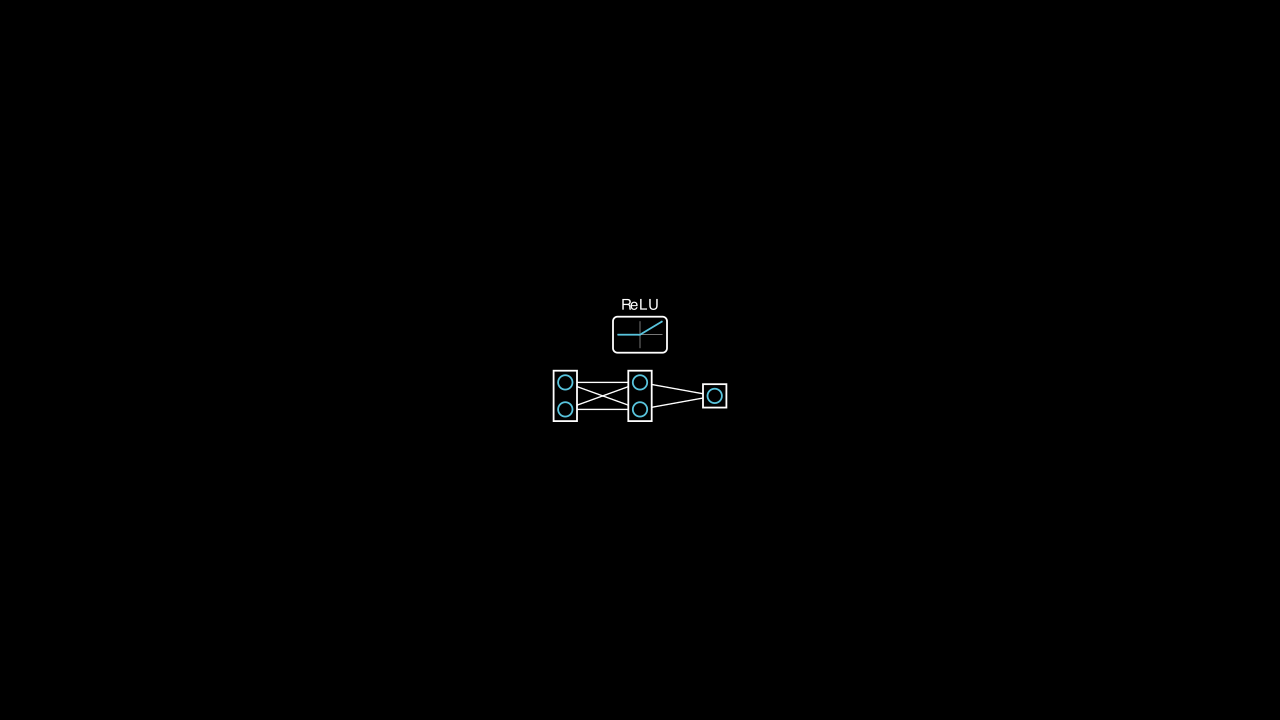

In [3]:
%%manim -qm XORNetworkScene

from manim_ml.neural_network import NeuralNetwork, FeedForwardLayer

class XORNetworkScene(Scene):
    def construct(self):
        # Define the neural network architecture
        nn = NeuralNetwork(
            [
                FeedForwardLayer(num_nodes=2),                         # Input layer (x1, x2)
                FeedForwardLayer(num_nodes=2, activation_function="ReLU"),  # Hidden layer (h1, h2)
                FeedForwardLayer(num_nodes=1), # Output layer (y)
            ],
            layer_spacing=0.4,
        )

        # Center and display the network
        nn.move_to(ORIGIN)
        self.add(nn)



Manim Community v0.19.0

Constructing layers
Current layer: FeedForwardLayer
Current layer: FeedForwardLayer
Current layer: FeedForwardLayer
Current layer: FeedForwardLayer
NeuralNetwork([
    FeedForwardLayer(z_index=3, title_text= , ),
    FeedForwardToFeedForward(input_layer=FeedForwardLayer,output_layer=FeedForwardLayer,)(z_index=2, title_text= , ),
    FeedForwardLayer(z_index=3, title_text= , ),
    FeedForwardToFeedForward(input_layer=FeedForwardLayer,output_layer=FeedForwardLayer,)(z_index=2, title_text= , ),
    FeedForwardLayer(z_index=3, title_text= , ),
    FeedForwardToFeedForward(input_layer=FeedForwardLayer,output_layer=FeedForwardLayer,)(z_index=2, title_text= , ),
    FeedForwardLayer(z_index=3, title_text= , ),
])


[07/13/25 12:37:03] INFO                                                                   ]8;id=820393;file:///Users/alex/pro/ai-engineer-roadmap-notebooks/.venv-manim/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=89808;file:///Users/alex/pro/ai-engineer-roadmap-notebooks/.venv-manim/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#886\886]8;;\
                             File ready at                                                                         
                             '/Users/alex/pro/ai-engineer-roadmap-notebooks/media/images/a                         
                             i-engineer-roadmap-notebooks/CustomNetworkScene_ManimCE_v0.19                         
                             .0.png'                                                                               
                                                                                                                   

                    INFO     Rendered CustomNetworkScene                                               ]8;id=256710;file:///Users/alex/pro/ai-engineer-roadmap-notebooks/.venv-manim/lib/python3.12/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=676362;file:///Users/alex/pro/ai-engineer-roadmap-notebooks/.venv-manim/lib/python3.12/site-packages/manim/scene/scene.py#255\255]8;;\
                             Played 0 animations                                                                   

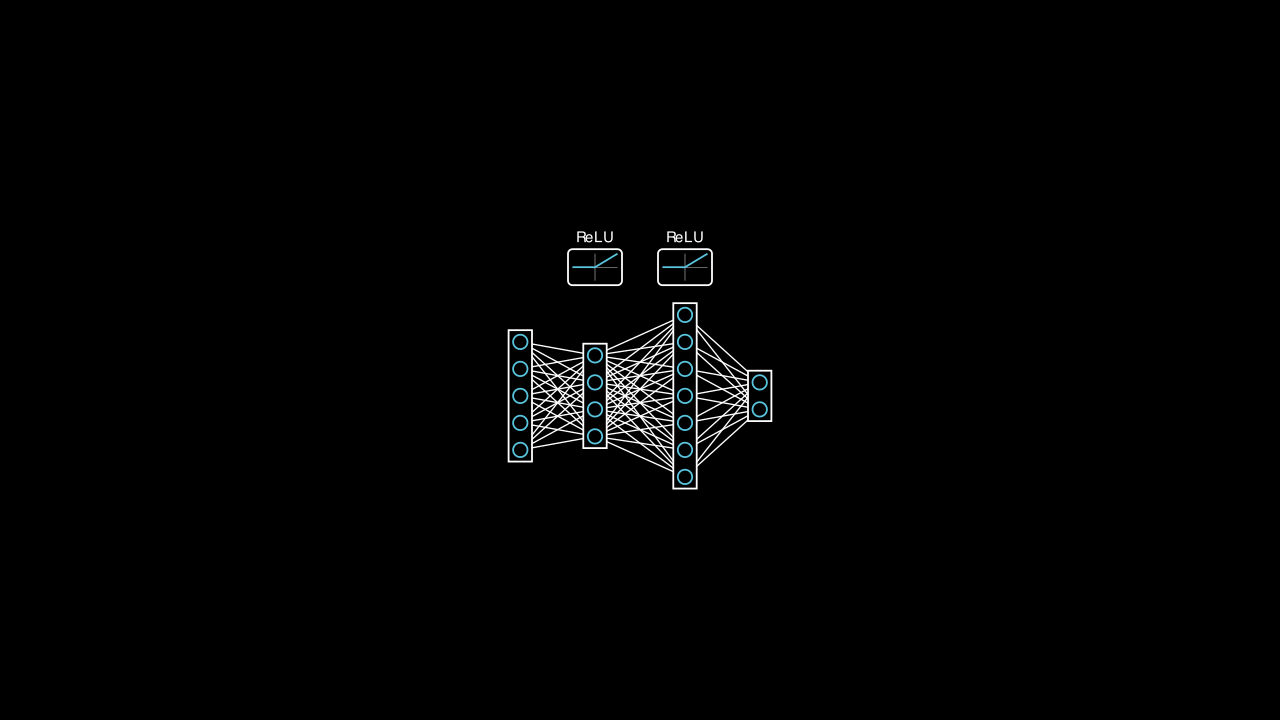

In [4]:
%%manim -qm CustomNetworkScene

class CustomNetworkScene(Scene):
    def construct(self):
        # Build the network
        nn = NeuralNetwork(
            [
                FeedForwardLayer(num_nodes=5),                         # Input layer (5-D)
                FeedForwardLayer(num_nodes=4, activation_function="ReLU"),  # Hidden 1 (4-D, ReLU)
                FeedForwardLayer(num_nodes=7, activation_function="ReLU"),  # Hidden 2 (7-D, ReLU)
                FeedForwardLayer(num_nodes=2),  # Output layer (2-D)
            ],
            layer_spacing=0.4,
        )

        # Center and show the network
        nn.move_to(ORIGIN)
        self.add(nn)


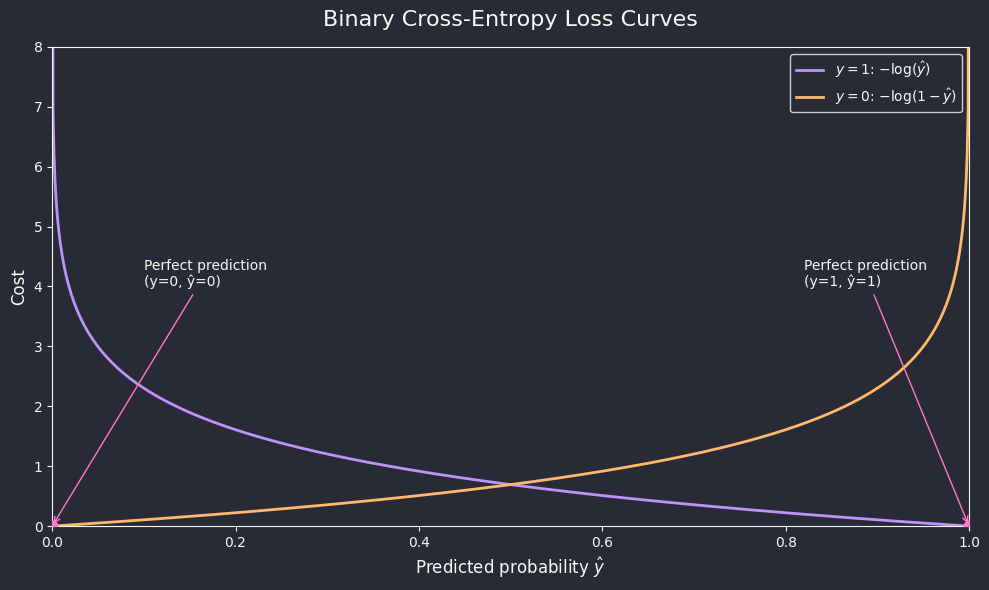

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Dracula palette
BG_COLOR = '#282a36'
FG_COLOR = '#f8f8f2'
PURPLE   = '#BD93F9'  # primary
ORANGE   = '#FFB86C'  # secondary
PINK     = '#FF79C6'

# Data for cost function curves
p = np.linspace(1e-6, 1 - 1e-6, 1000)  # avoid log(0)
cost_pos = -np.log(p)         # y = 1
cost_neg = -np.log(1 - p)     # y = 0

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Plot curves
ax.plot(p, cost_pos, color=PURPLE, linewidth=2, label=r"$y=1$: $-\log(\hat{y})$")
ax.plot(p, cost_neg, color=ORANGE, linewidth=2, label=r"$y=0$: $-\log(1-\hat{y})$")

# Highlight optimal predictions for clarity (optional annotation)
ax.scatter([1], [0], color=PINK, s=60, zorder=5)
ax.scatter([0], [0], color=PINK, s=60, zorder=5)
ax.annotate("Perfect prediction\n(y=1, ŷ=1)", xy=(1, 0), xytext=(0.82, 4),
            arrowprops=dict(arrowstyle='->', color=PINK), color=FG_COLOR, fontsize=10)
ax.annotate("Perfect prediction\n(y=0, ŷ=0)", xy=(0, 0), xytext=(0.10, 4),
            arrowprops=dict(arrowstyle='->', color=PINK), color=FG_COLOR, fontsize=10)

# Styling
ax.set_title("Binary Cross-Entropy Loss Curves", color=FG_COLOR, fontsize=16, pad=15)
ax.set_xlabel("Predicted probability $\\hat{y}$", color=FG_COLOR, fontsize=12)
ax.set_ylabel("Cost", color=FG_COLOR, fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 8)

ax.tick_params(colors=FG_COLOR)
for spine in ax.spines.values():
    spine.set_color(FG_COLOR)

legend = ax.legend(facecolor=BG_COLOR, edgecolor=FG_COLOR, labelcolor=FG_COLOR)
plt.tight_layout()


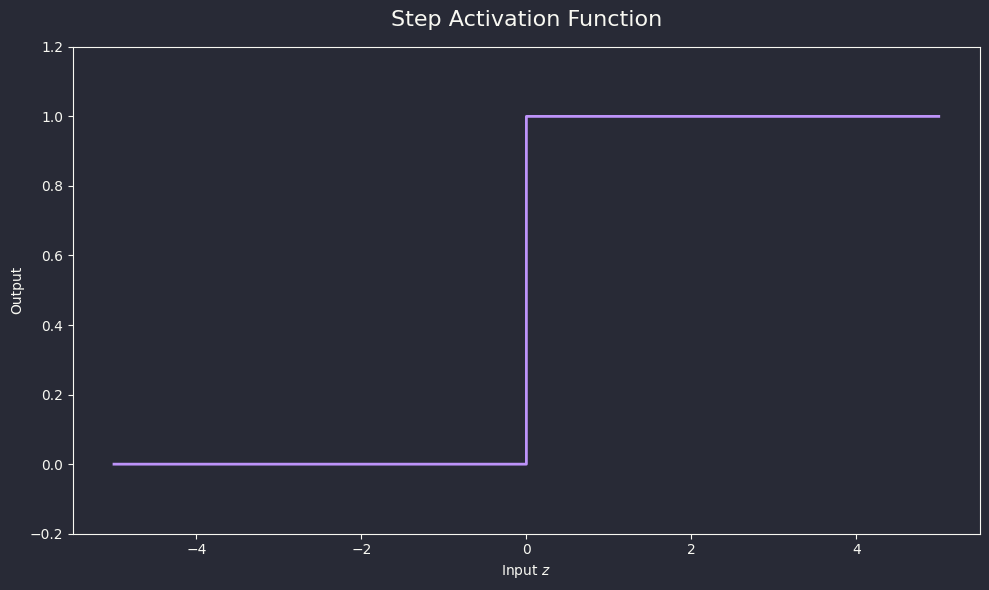

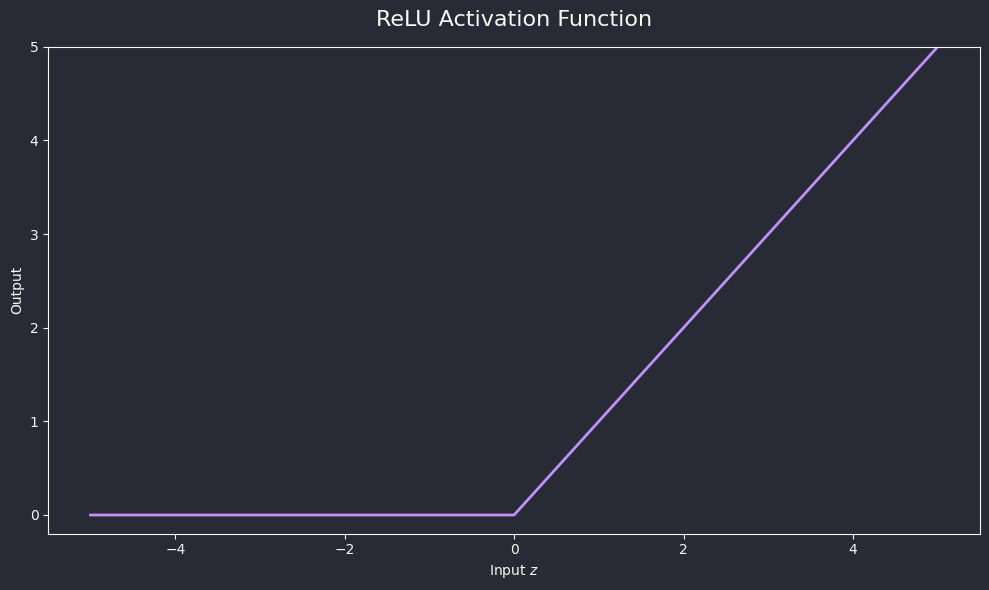

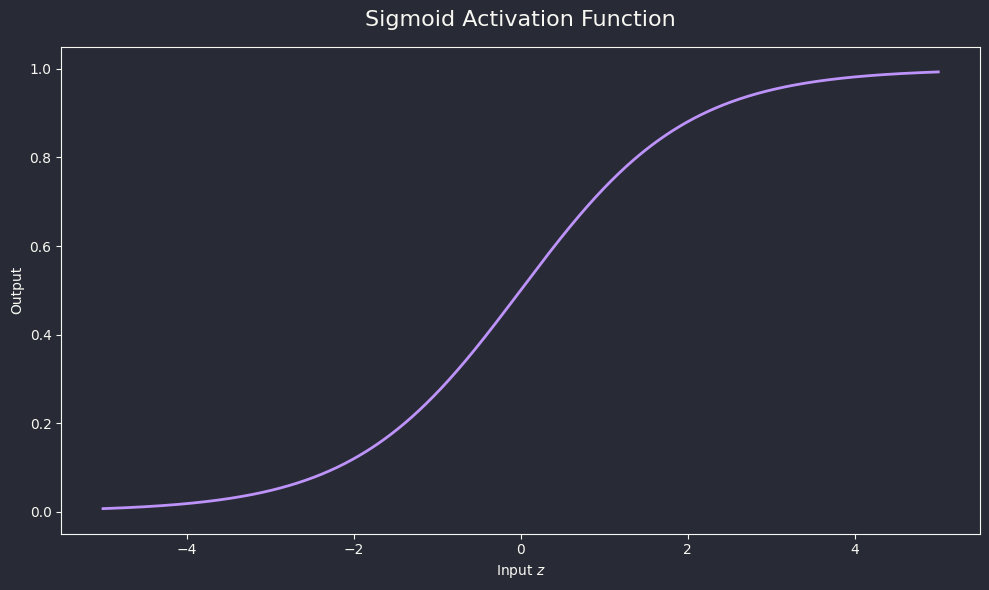

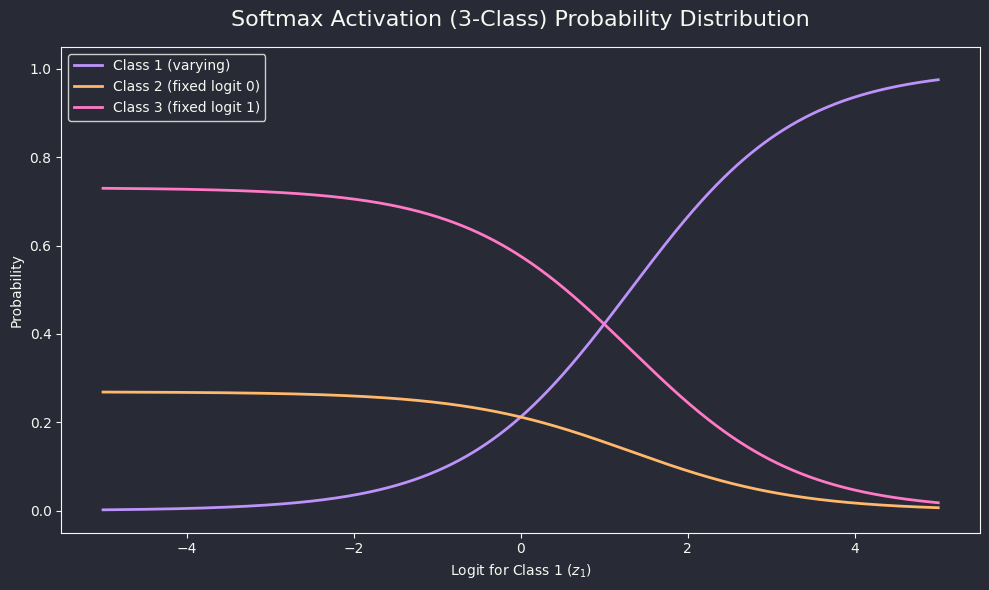

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Dracula palette
BG_COLOR = '#282a36'
FG_COLOR = '#f8f8f2'
PURPLE   = '#BD93F9'  # primary
ORANGE   = '#FFB86C'  # secondary
PINK     = '#FF79C6'  # tertiary

def style_axes(ax):
    """Apply Dracula styling to axes."""
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors=FG_COLOR)
    for spine in ax.spines.values():
        spine.set_color(FG_COLOR)

# 1. Step Function -----------------------------------------------------------
x = np.linspace(-5, 5, 1001)
y_step = (x >= 0).astype(int)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.step(x, y_step, where='post', color=PURPLE, linewidth=2)
ax.set_title("Step Activation Function", color=FG_COLOR, fontsize=16, pad=15)
ax.set_xlabel("Input $z$", color=FG_COLOR)
ax.set_ylabel("Output", color=FG_COLOR)
ax.set_ylim(-0.2, 1.2)
style_axes(ax)
plt.tight_layout()
plt.show()

# 2. ReLU Function -----------------------------------------------------------
y_relu = np.maximum(0, x)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.plot(x, y_relu, color=PURPLE, linewidth=2)
ax.set_title("ReLU Activation Function", color=FG_COLOR, fontsize=16, pad=15)
ax.set_xlabel("Input $z$", color=FG_COLOR)
ax.set_ylabel("Output", color=FG_COLOR)
ax.set_ylim(-0.2, 5)
style_axes(ax)
plt.tight_layout()
plt.show()

# 3. Sigmoid Function --------------------------------------------------------
y_sigmoid = 1 / (1 + np.exp(-x))

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.plot(x, y_sigmoid, color=PURPLE, linewidth=2)
ax.set_title("Sigmoid Activation Function", color=FG_COLOR, fontsize=16, pad=15)
ax.set_xlabel("Input $z$", color=FG_COLOR)
ax.set_ylabel("Output", color=FG_COLOR)
ax.set_ylim(-0.05, 1.05)
style_axes(ax)
plt.tight_layout()
plt.show()

# 4. Softmax Function (3-class example) --------------------------------------
xs = np.linspace(-5, 5, 1001)
probs = np.zeros((len(xs), 3))
for i, z0 in enumerate(xs):
    z = np.array([z0, 0.0, 1.0])            # vary only the first logit
    e = np.exp(z - np.max(z))               # stability shift
    probs[i] = e / e.sum()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.plot(xs, probs[:, 0], color=PURPLE, linewidth=2, label="Class 1 (varying)")
ax.plot(xs, probs[:, 1], color=ORANGE, linewidth=2, label="Class 2 (fixed logit 0)")
ax.plot(xs, probs[:, 2], color=PINK, linewidth=2, label="Class 3 (fixed logit 1)")
ax.set_title("Softmax Activation (3-Class) Probability Distribution", color=FG_COLOR, fontsize=16, pad=15)
ax.set_xlabel("Logit for Class 1 ($z_1$)", color=FG_COLOR)
ax.set_ylabel("Probability", color=FG_COLOR)
ax.set_ylim(-0.05, 1.05)
style_axes(ax)
legend = ax.legend(facecolor=BG_COLOR, edgecolor=FG_COLOR, labelcolor=FG_COLOR)
plt.tight_layout()
plt.show()


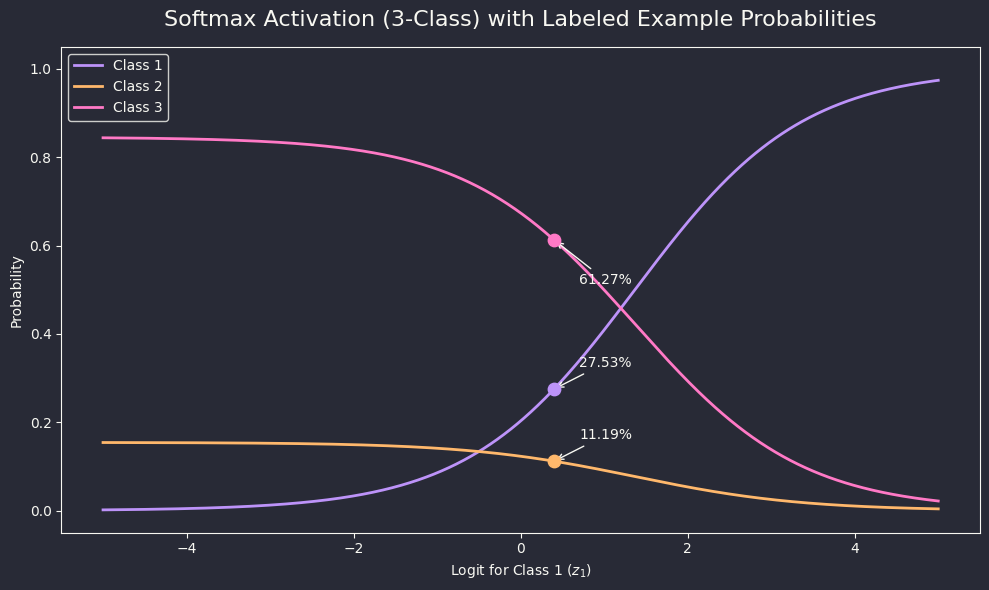

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Dracula palette
BG_COLOR = '#282a36'
FG_COLOR = '#f8f8f2'
PURPLE   = '#BD93F9'
ORANGE   = '#FFB86C'
PINK     = '#FF79C6'

def style_axes(ax):
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors=FG_COLOR)
    for spine in ax.spines.values():
        spine.set_color(FG_COLOR)

# Fixed logits for classes 2 and 3 from the example
z2_const = -0.5
z3_const = 1.2

# Range for z1 (class 1)
z1_vals = np.linspace(-5, 5, 1001)

# Compute softmax curves
probs = np.zeros((len(z1_vals), 3))
for i, z1 in enumerate(z1_vals):
    z = np.array([z1, z2_const, z3_const])
    e = np.exp(z - np.max(z))  # stability shift
    probs[i] = e / e.sum()

# Target point (example vector)
z1_target = 0.4
target_idx = np.argmin(np.abs(z1_vals - z1_target))
target_probs = probs[target_idx]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG_COLOR)

# Plot curves
ax.plot(z1_vals, probs[:, 0], color=PURPLE, linewidth=2, label="Class 1")
ax.plot(z1_vals, probs[:, 1], color=ORANGE, linewidth=2, label="Class 2")
ax.plot(z1_vals, probs[:, 2], color=PINK, linewidth=2, label="Class 3")

# Scatter labeled points at example logits
ax.scatter([z1_target], [target_probs[0]], color=PURPLE, s=80, zorder=5)
ax.scatter([z1_target], [target_probs[1]], color=ORANGE, s=80, zorder=5)
ax.scatter([z1_target], [target_probs[2]], color=PINK,   s=80, zorder=5)

# Annotate
ax.annotate(f"{target_probs[0]*100:.2f}%", xy=(z1_target, target_probs[0]),
            xytext=(z1_target+0.3, target_probs[0]+0.05),
            arrowprops=dict(arrowstyle='->', color=FG_COLOR), color=FG_COLOR, fontsize=10)
ax.annotate(f"{target_probs[1]*100:.2f}%", xy=(z1_target, target_probs[1]),
            xytext=(z1_target+0.3, target_probs[1]+0.05),
            arrowprops=dict(arrowstyle='->', color=FG_COLOR), color=FG_COLOR, fontsize=10)
ax.annotate(f"{target_probs[2]*100:.2f}%", xy=(z1_target, target_probs[2]),
            xytext=(z1_target+0.3, target_probs[2]-0.1),
            arrowprops=dict(arrowstyle='->', color=FG_COLOR), color=FG_COLOR, fontsize=10)

# Labels and style
ax.set_title("Softmax Activation (3-Class) with Labeled Example Probabilities", color=FG_COLOR, fontsize=16, pad=15)
ax.set_xlabel("Logit for Class 1 ($z_1$)", color=FG_COLOR)
ax.set_ylabel("Probability", color=FG_COLOR)
ax.set_ylim(-0.05, 1.05)
style_axes(ax)
legend = ax.legend(facecolor=BG_COLOR, edgecolor=FG_COLOR, labelcolor=FG_COLOR)
plt.tight_layout()

# Save
plt.show()
